# Basic Analysis

Some basic stuff ...

In [6]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("./classified_abstracts.json")

with DATA_PATH.open("r", encoding="utf-8") as f:
    records = json.load(f)

raw_df = pd.DataFrame(records)
raw_df.head()

,year,title,authors,doi,url,abstract,categories,reason
0,2020,A game-theoretic approach for the multi-object...,"Fatma Laidoui, Fatima Benbouzid-Si Tayeb, Mali...",10.1145/3341105.3375778,https://dblp.org/rec/conf/sac/LaidouiTBL20,This study proposes a novel game theory based ...,[Undefined],The paper focuses on a game-theoretic approach...
1,2020,A Performance Analysis of Adaptive Streaming A...,"Carlos Renato Storck, Fátima de L. P. Duarte-F...",10.1109/ISCC50000.2020.9219682,https://dblp.org/rec/conf/iscc/StorckD20,Adaptive streaming is a technique used in mult...,[Undefined],The paper focuses on the performance analysis ...
2,2020,A Vehicle-Centric Probabilistic Approach to Vi...,"Carlos Renato Storck, Guilherme G. de O. Silva...",10.1109/ISCC50000.2020.9219691,https://dblp.org/rec/conf/iscc/StorckSD20,The fifth generation (5G) cellular networks te...,[Undefined],The paper focuses on a technical approach to v...
3,2020,The Effects of Heat Treatment on Fatigue Stren...,"Yushu Wang, Yikun Wang, Yicheng (Frederick) Jiang",10.1145/3421766.3421871,https://dblp.org/rec/conf/aiam/WangWJ20,"In this paper, the mechanical performance of w...",[Undefined],The paper focuses on mechanical performance an...
4,2020,Exploring Visual Attention and Machine Learnin...,"Leonardo Souza Silva, Renull Vinicius Aranha, ...",10.1109/CBMS49503.2020.00035,https://dblp.org/rec/conf/cbms/SilvaARNM20,Temporal data visualization supports planning ...,[Undefined],The paper focuses on the application of visual...


In [2]:
category_df = raw_df[["year", "categories"]].explode("categories").rename(columns={"categories": "category"})
category_df["category"] = category_df["category"].fillna("Undefined")
category_df["year"] = pd.to_numeric(category_df["year"], errors="coerce")
category_df = category_df.dropna(subset=["year"])
category_df["year"] = category_df["year"].astype(int)

category_counts = (
    category_df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

category_counts.head(10)

,category,count
0,Bias & Inequality,516
1,Undefined,273
2,Disempowerment,271
3,Authoritarianism,99
4,Robustness,74
5,Misinformation,55
6,Extinction Risk,2


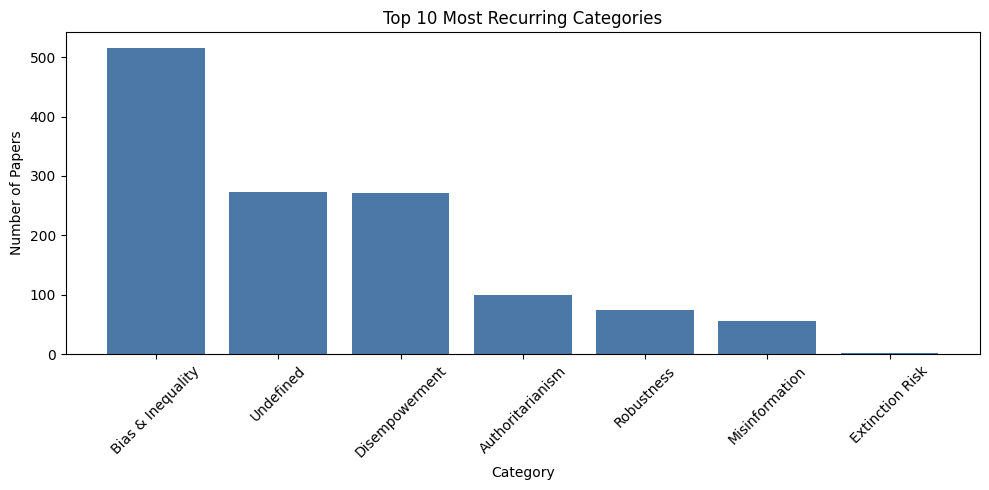

In [3]:
top_n = 10
plot_counts = category_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_counts["category"], plot_counts["count"], color="#4C78A8")
ax.set_title(f"Top {top_n} Most Recurring Categories")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Papers")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [4]:
trend_categories = category_counts.loc[category_counts["category"] != "Undefined", "category"].head(6).tolist()
if not trend_categories:
    trend_categories = category_counts.head(6)["category"].tolist()

yearly_counts = (
    category_df[category_df["category"].isin(trend_categories)]
    .groupby(["year", "category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

yearly_counts

category,Authoritarianism,Bias & Inequality,Disempowerment,Extinction Risk,Misinformation,Robustness
year,,,,,,
2020,6,9,7,0,5,16
2021,10,68,34,0,2,9
2022,26,129,57,1,15,16
2023,25,127,63,0,6,7
2024,24,129,75,1,17,17
2025,8,54,35,0,10,9


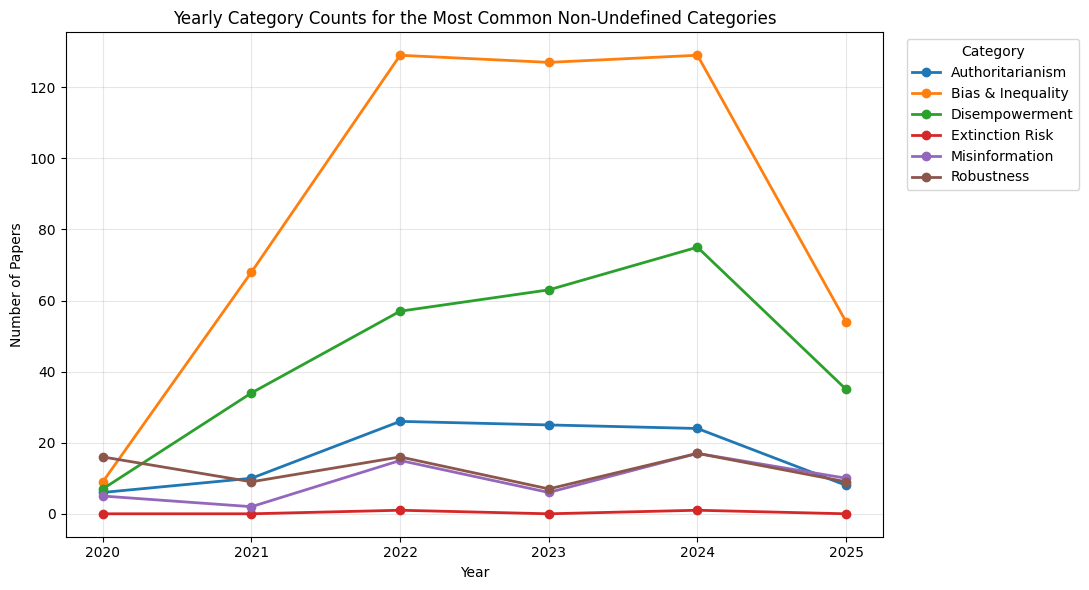

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
for category in yearly_counts.columns:
    ax.plot(yearly_counts.index, yearly_counts[category], marker="o", linewidth=2, label=category)

ax.set_title("Yearly Category Counts for the Most Common Non-Undefined Categories")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Papers")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()